In [3]:
import io, copy, random, time, contextlib
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

from UQpy.distributions import Uniform, Normal, JointIndependent
from UQpy.sampling import ThetaCriterionPCE, LatinHypercubeSampling
from UQpy.sampling.stratified_sampling.latin_hypercube_criteria import MaxiMin, DistanceMetric

from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

import SAPCE  # Pomocne funkce okolo SAPCE / PCE


In [4]:
def split_pce_by_output(pce_multi):  # Rozdeli multioutput PCE na jednotlive vystupy.
    C = np.asarray(pce_multi.coefficients)  # Theta chce seznam PCE pro vystupy.
    C = C.reshape(-1, 1) if C.ndim == 1 else C
    out = []
    for j in range(C.shape[1]):
        p = copy.deepcopy(pce_multi)
        p.coefficients = C[:, j].reshape(-1, 1)
        out.append(p)
    return out

  # https://docs.python.org/3/library/functions.html
def predict_pce_list(pce_list, X):  # Spocita predikce pro kazdy PCE model.
    out = []  # Potrebuju jednotny vystup predikci.
    for p in pce_list:
        y = None
        for m in ("predict", "evaluate", "__call__", "run"):
            if hasattr(p, m):
                y = np.asarray(getattr(p, m)(X))
                break
        if y is None:
            raise RuntimeError("PCE nema metodu pro predikci.")
        y = y.reshape(-1, 1) if y.ndim == 1 else y
        out.append(y)
    return np.hstack(out)

# -https://uqpyproject.readthedocs.io/en/latest/surrogates/pce/pce.html
def uqpy_val_error(pce_obj, X_eval, Y_eval):  # Vola pce.validation_error(X, Y) jako v kodu 2. 
    e = np.asarray(pce_obj.validation_error(X_eval, Y_eval), float)
    e = e.reshape(1) if e.ndim == 0 else e
    return e.reshape(-1)


def try_get_loo_error(pce_obj, X_train=None, Y_train=None):  # Zkusi vytahnout LOO chybu z objektu.
    for name in ["leave_one_out_error", "leaveoneout_error", "loo_error", "LOO_error", "loo", "LOO"]:  # Chci LOO i kdyz neni standardni.
        if not hasattr(pce_obj, name):
            continue
        attr = getattr(pce_obj, name)
        if not callable(attr):
            return np.asarray(attr)
        try:
            return np.asarray(attr())
        except TypeError:
            pass
        if (X_train is not None) and (Y_train is not None):
            try:
                return np.asarray(attr(X_train, Y_train))
            except Exception:
                pass
    n_out = Y_train.shape[1] if Y_train is not None else 1  # Kdyz nic nefunguje, vratim NaN.
    return np.full((n_out,), np.nan, float)  # Nezastavim beh celeho experimentu.

# https://www.sciencedirect.com/science/article/pii/S0307904X24004992
# https://github.com/dlouk/mvsa-pce
def fit_sapce_pce(joint, X_train, Y_train, n_inputs, deg, cr, max_cond=1e8, silent=True):  # Postavi SAPCE a vrati multioutput PCE.
    try_deg = [deg] + ([5] if deg >= 7 else []) + ([3] if deg >= 5 else []) + [1]  # Stejny fit pro vsechny metody.
    try_cr = [cr, cr / 10.0, 0.0]
    last_err = None
    for d in try_deg:
        for c in try_cr:
            try:
                sapce = SAPCE.SensitivityAdaptivePCE(
                    pdf=joint,
                    exp_design_in=X_train,
                    exp_design_out=Y_train,
                    max_partial_degree=d,
                    num_inputs=n_inputs,
                )
                if silent:
                    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                        sapce.construct_adaptive_basis(max_condition_number=max_cond)
                        sapce.construct_pruned_pce(cr=c)
                else:
                    sapce.construct_adaptive_basis(max_condition_number=max_cond)
                    sapce.construct_pruned_pce(cr=c)
                pce = getattr(sapce, "pce", None)
                if (pce is not None) and hasattr(pce, "coefficients"):
                    return pce
            except Exception as e:
                last_err = e
    raise RuntimeError(f"SAPCE failed. Last error: {repr(last_err)}")

#https://uqpyproject.readthedocs.io/en/stable/distributions/continuous_1d_collection.html
def dist_loc_scale(dist):  # Vytahne loc a scale pro skalu vzdalenosti.
    if hasattr(dist, "loc") and hasattr(dist, "scale"):
        try:
            return float(dist.loc), float(dist.scale)  # Spravne vahovani vzdalenosti v prostoru.
        except Exception:
            pass
    if hasattr(dist, "mean") and hasattr(dist, "std"):
        try:
            return float(dist.mean), float(dist.std)  # Spravne vahovani vzdalenosti v prostoru.
        except Exception:
            pass
    if hasattr(dist, "parameters"):
        try:
            p = dist.parameters
            loc = p.get("loc", p.get("mean", p.get("mu", 0.0)))
            sc = p.get("scale", p.get("std", p.get("sigma", 1.0)))
            return float(loc), float(sc)  # Spravne vahovani vzdalenosti v prostoru.
        except Exception:
            pass
    return 0.0, 1.0

#https://uqpyproject.readthedocs.io/en/latest/sampling/latin_hypercube.html
def pick_lhs_candidates(joint, X_cand, cand_idx, n_select, seed, xmin, xmax):  # Vybere realne body podle LHS cileni.  
    rng = np.random.RandomState(seed)  # LHS ma lepe pokryt prostor vstupu.
    lhs = LatinHypercubeSampling(
        distributions=joint.marginals,
        nsamples=int(n_select),
        random_state=rng,
        criterion=MaxiMin(metric=DistanceMetric.CHEBYSHEV),
    )
    targets = np.asarray(lhs.samples, float)

    loc_sc = [dist_loc_scale(m) for m in joint.marginals]
    loc = np.array([a for a, _ in loc_sc], float)
    sc = np.array([b for _, b in loc_sc], float)
    sc = np.where(np.isfinite(sc) & (sc > 0), sc, 1.0)

    Zc = (np.asarray(X_cand, float) - loc) / sc
    Zt = (targets - loc) / sc

    D = cdist(Zt, Zc, metric="sqeuclidean")  # Hungarian prirazeni minimalizuje globalni sumu vzdalenosti.
    _, col = linear_sum_assignment(D)  # Neztratim kvalitu greedy vyberem.
    return np.asarray(cand_idx, int)[col].astype(int)

# https://uqpyproject.readthedocs.io/en/stable/sampling/theta_criterion.html
def pick_theta_candidates(
    joint,
    X_all,
    Y_all,
    start_idx,
    cand_idx,
    n_inputs,
    deg,
    cr,
    max_cond,
    theta_out_idx,
    theta_focus_k,
    batch_size,
    n_total_add,
    seed,
    X_test,
    Y_test,
):  # Vybere body pomoci Theta po krocich.
    random.seed(seed)  # Chci aktivne zlepsit nepresne oblasti.

    X_train = X_all[start_idx].copy()
    Y_train_all = Y_all[start_idx][:, theta_out_idx].copy()

    X_candidates = X_all[cand_idx].copy()
    cand_ids = np.asarray(cand_idx, int).copy()

    selected = []
    refit_initial = min(20, n_total_add)

    while len(selected) < n_total_add:
        refit_every = 1 if len(selected) < refit_initial else min(batch_size, batch_size)  # Na zacatku refituju po kazdem bodu.
        pce_full = fit_sapce_pce(joint, X_train, Y_train_all, n_inputs, deg, cr, max_cond=max_cond, silent=True)  # Zmensim redundanci vyberu bodu.

        Yt_sub = Y_test[:, theta_out_idx]  # Spocitam chybu na testu.
        err_full = uqpy_val_error(pce_full, X_test, Yt_sub).reshape(-1)  # Vahy mirim na nejhorsi vystupy.

        err_work = np.where(np.isfinite(err_full), err_full, -np.inf)  # Najdu nejhorsi vystupy.
        k_focus = min(max(1, theta_focus_k), err_work.size)  # Theta se soustredi na maxima.
        worst = np.argsort(err_work)[-k_focus:].astype(int)

        Y_focus = Y_train_all[:, worst].copy()  # Standardizuji jen pro selection.
        mu = np.nanmean(Y_focus, axis=0)  # Theta neni ovlivnena meritkem vystupu.
        sig = np.nanstd(Y_focus, axis=0)
        mu = np.where(np.isfinite(mu), mu, 0.0)
        sig = np.where(np.isfinite(sig) & (sig > 0), sig, 1.0)
        Y_std = (Y_focus - mu) / sig
        Y_std = np.where(np.isfinite(Y_std), Y_std, 0.0)

        pce_sel = fit_sapce_pce(joint, X_train, Y_std, n_inputs, deg, cr, max_cond=max_cond, silent=True)  # Postavim selection PCE na standardizaci.
        if not hasattr(pce_sel, "polynomial_basis"):  # Theta ocekava PolynomialChaosExpansion.
            raise RuntimeError("PCE nema atribut polynomial_basis (Theta ocekava PolynomialChaosExpansion).")
        pb = getattr(pce_sel, "polynomial_basis", None)
        if pb is None:
            raise RuntimeError("PCE.polynomial_basis je None (Theta ocekava PolynomialChaosExpansion).")
        if (not hasattr(pb, "distributions")) or (getattr(pb, "distributions") is None):
            try:
                pb.distributions = joint.marginals 
            except Exception:
                pass
        if (not hasattr(pb, "distributions")) or (getattr(pb, "distributions") is None):
            raise RuntimeError("PCE.polynomial_basis.distributions chybi nebo je None (Theta ocekava distributions).")
        try:
            if len(pb.distributions) != int(n_inputs):
                raise RuntimeError(f"PCE.polynomial_basis.distributions ma delku {len(pb.distributions)}, ale n_inputs={n_inputs}.")
        except TypeError:
            pass

        theta = ThetaCriterionPCE(split_pce_by_output(pce_sel))  # Theta bere list pro vystupy.

        w = err_full[worst].astype(float)  # Vahy udelam podle test chyb.
        w = np.where(np.isfinite(w) & (w > 0), w, 0.0)  # Tlacim dolu max a p95 chyby.
        pos = w[w > 0]
        denom = float(np.percentile(pos, 95)) if pos.size else 1.0
        denom = -min(-denom, -1e-12)
        w = w / denom

        block_pick = min(refit_every, n_total_add - len(selected))  # Vyberu par bodu v bloku.
        block_ids = []  # Pozdeji setrim cas refitu.

        for _ in range(block_pick):
            if len(selected) >= n_total_add:
                break
            if X_candidates.shape[0] == 0:
                break

            i = int(theta.run(X_train, X_candidates, pce_weights=w))
            nid = int(cand_ids[i])

            selected.append(nid)
            block_ids.append(nid)

            X_candidates = np.delete(X_candidates, i, axis=0)  # Odeberu bod z kandidatu.
            cand_ids = np.delete(cand_ids, i, axis=0)  # Nevyberu stejny bod dvakrat.

            if refit_every == 1:
                X_train = np.vstack([X_train, X_all[nid].reshape(1, -1)])  # Pri refitu kazdy krok hned doplnim data.
                Y_train_all = np.vstack([Y_train_all, Y_all[nid, theta_out_idx].reshape(1, -1)])  # Dalsi vyber pouzije aktualni model.

        if refit_every != 1 and len(block_ids):
            X_train = np.vstack([X_train, X_all[block_ids]])  # Pri batch refitu doplnim data az po bloku.
            Y_train_all = np.vstack([Y_train_all, Y_all[block_ids][:, theta_out_idx]])  # Dalsi blok uz refitne novy PCE.

    return np.array(selected, int)

# https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.set_yscale.html
def set_log_if_ok(ax, y_values):  # Prepne osu y na log, kdyz to jde.
    y = np.asarray(y_values, float).ravel()  # Leppe vidim rozdily v chybach.
    y = y[np.isfinite(y)]
    if y.size and np.all(y > 0):
        ax.set_yscale("log")


def safe_percentile(x, q):  # Spocita percentil bez padu na NaN.
    x = np.asarray(x, float).ravel()  # Stabilni souhrn i pri NaN.
    x = x[np.isfinite(x)]
    return float(np.percentile(x, q)) if x.size else np.nan



In [5]:
#  https://matplotlib.org/stable/gallery/misc/multipage_pdf.html
def plot_pdf_summary(results_df, out_pdf="comparison_plots.pdf"):  # Vykresli mean a percentily do PDF.
    metrics = [
        (
            "UQpy validation error",
            ("uqpy_val_err_mean_theta", "uqpy_val_err_p05_theta", "uqpy_val_err_p95_theta"),
            ("uqpy_val_err_mean_random", "uqpy_val_err_p05_random", "uqpy_val_err_p95_random"),
            ("uqpy_val_err_mean_lhs", "uqpy_val_err_p05_lhs", "uqpy_val_err_p95_lhs"),
        ),
        (
            "LOO error",
            ("loo_err_mean_theta", "loo_err_p05_theta", "loo_err_p95_theta"),
            ("loo_err_mean_random", "loo_err_p05_random", "loo_err_p95_random"),
            ("loo_err_mean_lhs", "loo_err_p05_lhs", "loo_err_p95_lhs"),
        ),
    ]  # PDF slouzi jako report celeho behu.
    start_sizes = sorted(results_df["start_size"].unique().tolist())
    degrees = sorted(results_df["degree"].unique().tolist())

    with PdfPages(out_pdf) as pdf:
        fig = plt.figure(figsize=(11.7, 8.3))  # Udelam titulni stranu.
        ax = fig.add_axes([0, 0, 1, 1])  # Rychle vidim nastaveni reportu.
        ax.axis("off")
        ax.text(0.05, 0.92, "SAPCE: Theta vs Random vs LHS", fontsize=20, va="top")
        ax.text(0.05, 0.82, f"start_size: {start_sizes}", fontsize=12, va="top")
        ax.text(0.05, 0.78, f"degrees: {degrees}", fontsize=12, va="top")
        ax.text(0.05, 0.74, "Osa x = pocet trenovacich bodu.", fontsize=12, va="top")
        pdf.savefig(fig)
        plt.close(fig)

        for s0 in start_sizes:
            sub_s = results_df[results_df["start_size"] == s0].copy()
            for title, th_cols, ra_cols, lh_cols in metrics:
                cols = list(th_cols) + list(ra_cols) + list(lh_cols)
                g = sub_s.groupby(["degree", "n_added"], as_index=False)[cols].mean().sort_values(["degree", "n_added"])
                g["n_train"] = g["n_added"].astype(int) + int(s0)

                ncols = 2
                nrows = int(np.ceil(len(degrees) / min(ncols, ncols)))
                fig, axes = plt.subplots(nrows, ncols, figsize=(11.7, 8.3), sharex=True, sharey=False)
                axes = np.atleast_1d(axes).ravel()
                fig.suptitle(f"{title} | start_size={s0}", fontsize=14, y=0.98)

                for i, deg in enumerate(degrees):
                    ax = axes[i]
                    d = g[g["degree"] == deg].copy()
                    if d.shape[0] == 0:
                        ax.axis("off")
                        continue

                    th_mean, th_p05, th_p95 = th_cols
                    ra_mean, ra_p05, ra_p95 = ra_cols
                    lh_mean, lh_p05, lh_p95 = lh_cols

                    line_th = ax.plot(d["n_train"], d[th_mean], label="Theta")[0]  # Barvy jsou konzistentni pro cteni.
                    c_th = line_th.get_color()  # Min/max hodnoty krivky stejnou barvou jako originalni krivka.
                    ax.plot(d["n_train"], d[th_p05], linestyle="--", color=c_th, label="Theta p05")
                    ax.plot(d["n_train"], d[th_p95], linestyle=":", color=c_th, label="Theta p95")

                    line_ra = ax.plot(d["n_train"], d[ra_mean], label="Random")[0]
                    c_ra = line_ra.get_color()
                    ax.plot(d["n_train"], d[ra_p05], linestyle="--", color=c_ra, label="Random p05")
                    ax.plot(d["n_train"], d[ra_p95], linestyle=":", color=c_ra, label="Random p95")

                    line_lh = ax.plot(d["n_train"], d[lh_mean], label="LHS")[0]
                    c_lh = line_lh.get_color()
                    ax.plot(d["n_train"], d[lh_p05], linestyle="--", color=c_lh, label="LHS p05")
                    ax.plot(d["n_train"], d[lh_p95], linestyle=":", color=c_lh, label="LHS p95")

                    y_all = np.r_[
                        d[th_mean].values, d[th_p05].values, d[th_p95].values,
                        d[ra_mean].values, d[ra_p05].values, d[ra_p95].values,
                        d[lh_mean].values, d[lh_p05].values, d[lh_p95].values,
                    ]
                    set_log_if_ok(ax, y_all)

                    ax.set_title(f"degree={deg}")
                    ax.set_xlabel("n_train")
                    ax.set_ylabel("error")
                    ax.grid(True, which="both", alpha=0.3)
                    ax.legend(fontsize=8, ncol=2)

                for j in range(i + 1, len(axes)):
                    axes[j].axis("off")

                pdf.savefig(fig)
                plt.close(fig)


def plot_pdf_multiline(error_store, out_pdf="comparison_multiline_errors.pdf", max_curves=None):  # Vykresli per-output krivky do PDF.
    keys = sorted(error_store.keys(), key=lambda k: (k[0], k[1], k[2], k[3]))  # Vidim rozptyl mezi vystupy.
    with PdfPages(out_pdf) as pdf:
        fig = plt.figure(figsize=(11.7, 8.3))  # Udelam titulni stranu.
        ax = fig.add_axes([0, 0, 1, 1])  # Vysvetli styl vykresleni.
        ax.axis("off")
        ax.text(0.05, 0.92, "SAPCE: Multi-line errors (one line per output)", fontsize=20, va="top")
        ax.text(0.05, 0.86, "Log y-axis is enabled when all values are > 0.", fontsize=12, va="top")
        ax.text(0.05, 0.82, "No legend (too many curves).", fontsize=12, va="top")
        pdf.savefig(fig)
        plt.close(fig)

        for (start_size, degree, method, metric) in keys:
            pack = error_store[(start_size, degree, method, metric)]
            n_train = np.asarray(pack["n_train"], int)
            E = np.asarray(pack["errs"], float)

            order = np.argsort(n_train)
            n_train = n_train[order]
            E = E[order, :]

            n_steps, n_out = E.shape
            n_plot = n_out if (max_curves is None) else int(min(max_curves, n_out))

            fig, ax = plt.subplots(figsize=(11.7, 8.3))
            for j in range(n_plot):
                ax.plot(n_train, E[:, j], linewidth=0.8, alpha=0.9)

            set_log_if_ok(ax, E[:, :n_plot].ravel())

            ax.set_title(f"{metric} per-output | method={method} | start_size={start_size} | degree={degree} | curves={n_plot}")
            ax.set_xlabel("$n_{sim}$" if False else "$n_{train}$")  # jen popisek, osa je n_train
            ax.set_ylabel("MSE$_{log}$")
            ax.grid(True, which="both", alpha=0.3)

            pdf.savefig(fig)
            plt.close(fig)


def plot_console_means(results_df):  # Pridej do konzole grafy kde bude porovnani LHS vs Random vs Theta.
    metrics = [
        ("UQpy validation error", "uqpy_val_err_mean_theta", "uqpy_val_err_mean_random", "uqpy_val_err_mean_lhs"),
        ("LOO error", "loo_err_mean_theta", "loo_err_mean_random", "loo_err_mean_lhs"),
    ]  # Ale bez min a max hodnot.
    start_sizes = sorted(results_df["start_size"].unique().tolist())
    degrees = sorted(results_df["degree"].unique().tolist())

    for s0 in start_sizes:
        sub_s = results_df[results_df["start_size"] == s0].copy()
        for title, th_mean, ra_mean, lh_mean in metrics:
            g = sub_s.groupby(["degree", "n_added"], as_index=False)[[th_mean, ra_mean, lh_mean]].mean().sort_values(["degree", "n_added"])
            g["n_train"] = g["n_added"].astype(int) + int(s0)

            ncols = 2
            nrows = int(np.ceil(len(degrees) / min(ncols, ncols)))
            fig, axes = plt.subplots(nrows, ncols, figsize=(11.7, 8.3), sharex=True, sharey=False)
            axes = np.atleast_1d(axes).ravel()
            fig.suptitle(f"{title} (mean only) | start_size={s0}", fontsize=14, y=0.98)

            for i, deg in enumerate(degrees):
                ax = axes[i]
                d = g[g["degree"] == deg].copy()
                if d.shape[0] == 0:
                    ax.axis("off")
                    continue

                ax.plot(d["n_train"], d[th_mean], label="Theta")
                ax.plot(d["n_train"], d[ra_mean], label="Random")
                ax.plot(d["n_train"], d[lh_mean], label="LHS")

                set_log_if_ok(ax, np.r_[d[th_mean].values, d[ra_mean].values, d[lh_mean].values])

                ax.set_title(f"degree={deg}")
                ax.set_xlabel("n_train")
                ax.set_ylabel("error")
                ax.grid(True, which="both", alpha=0.3)
                ax.legend(fontsize=9, ncol=1)

            for j in range(i + 1, len(axes)):
                axes[j].axis("off")

    plt.show()

Oakwood_NVM.csv loaded: X=(1000, 12), Y_N=(1000, 113)
degree_list=[6, 10]
start_size_list=[30, 70]
final_train_size=100
batch_size=5, cr=1e-06
n_test_target=100
seed=1

Fixed split
n_start=30, n_add_total=70, n_test=100
start_idx: n=30
test_idx : n=100
cand_idx : n=870

RUN: start_size=30 | seed=1 | degree=6

RUN: start_size=30 | seed=1 | degree=10

Fixed split
n_start=70, n_add_total=30, n_test=100
start_idx: n=70
test_idx : n=100
cand_idx : n=830

RUN: start_size=70 | seed=1 | degree=6

RUN: start_size=70 | seed=1 | degree=10

Total runtime: 138.80 s
Saved: results_theta_random_lhs_uqpy_loo_excel.csv
Saved: results_theta_random_lhs_uqpy_loo.xlsx
LOO NaN rows: 0
Saved: comparison_theta_random_lhs.pdf
Saved: comparison_theta_random_lhs_multiline.pdf


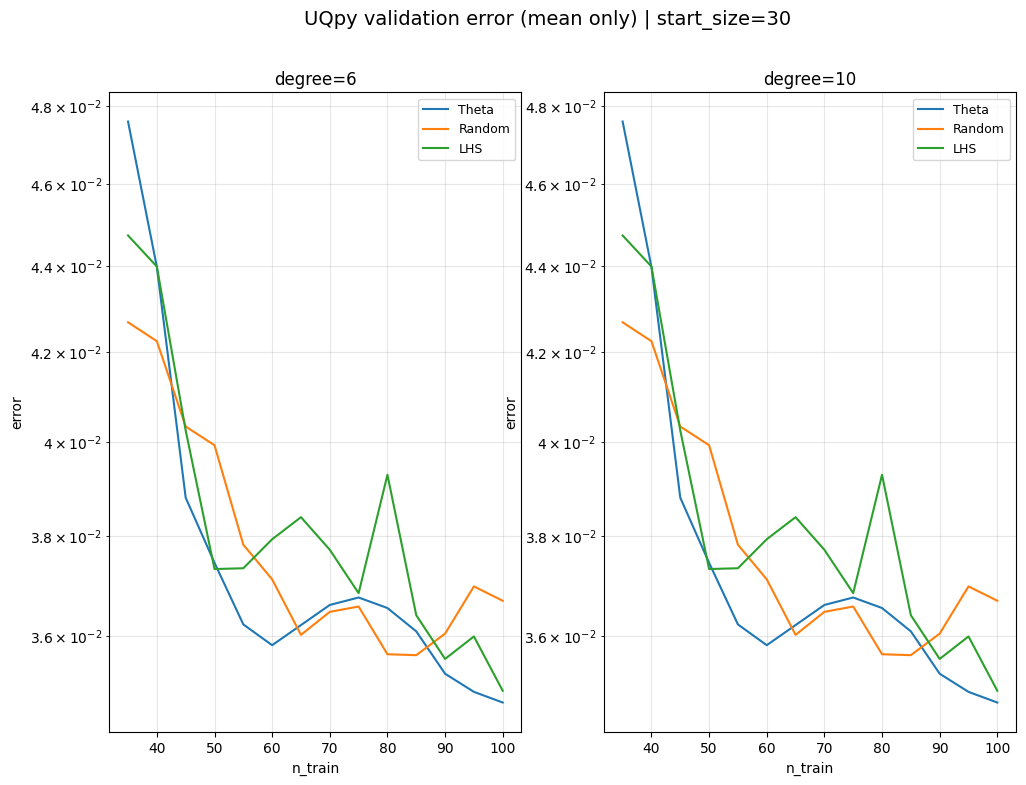

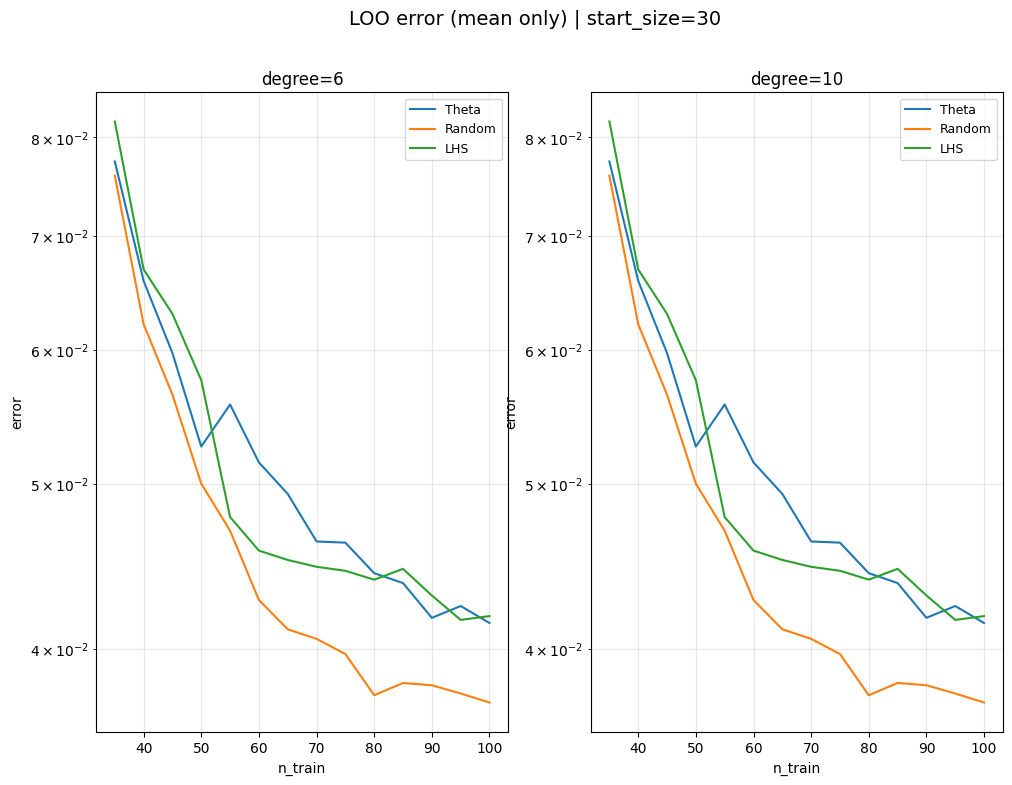

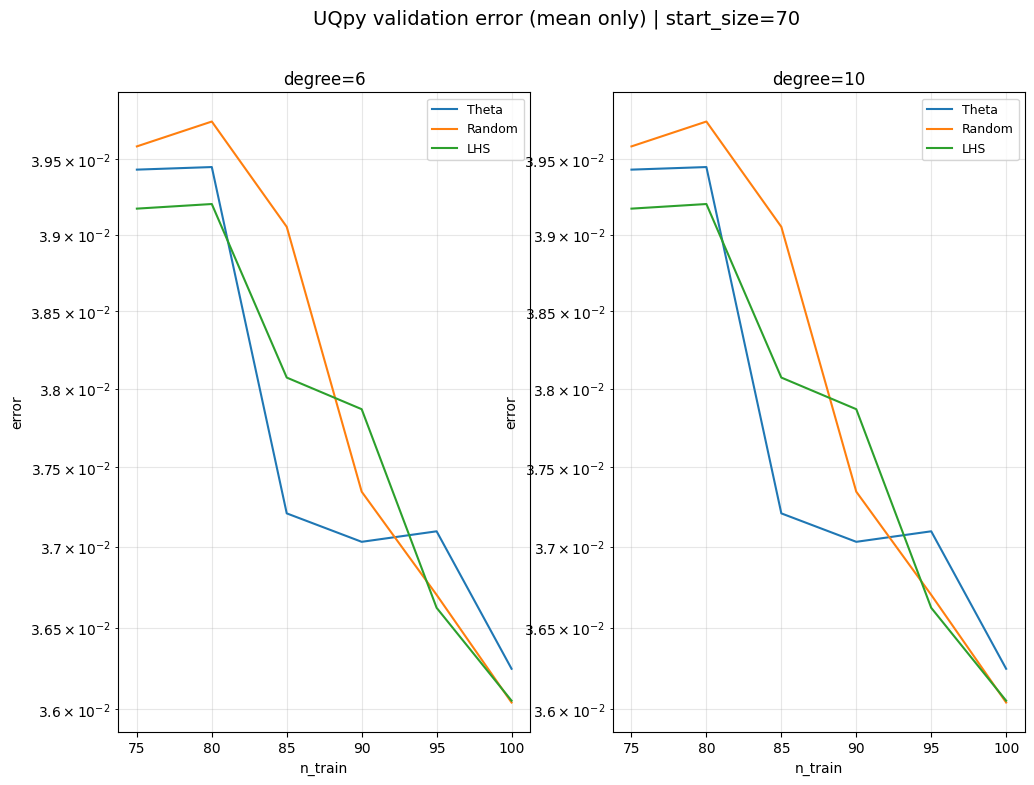

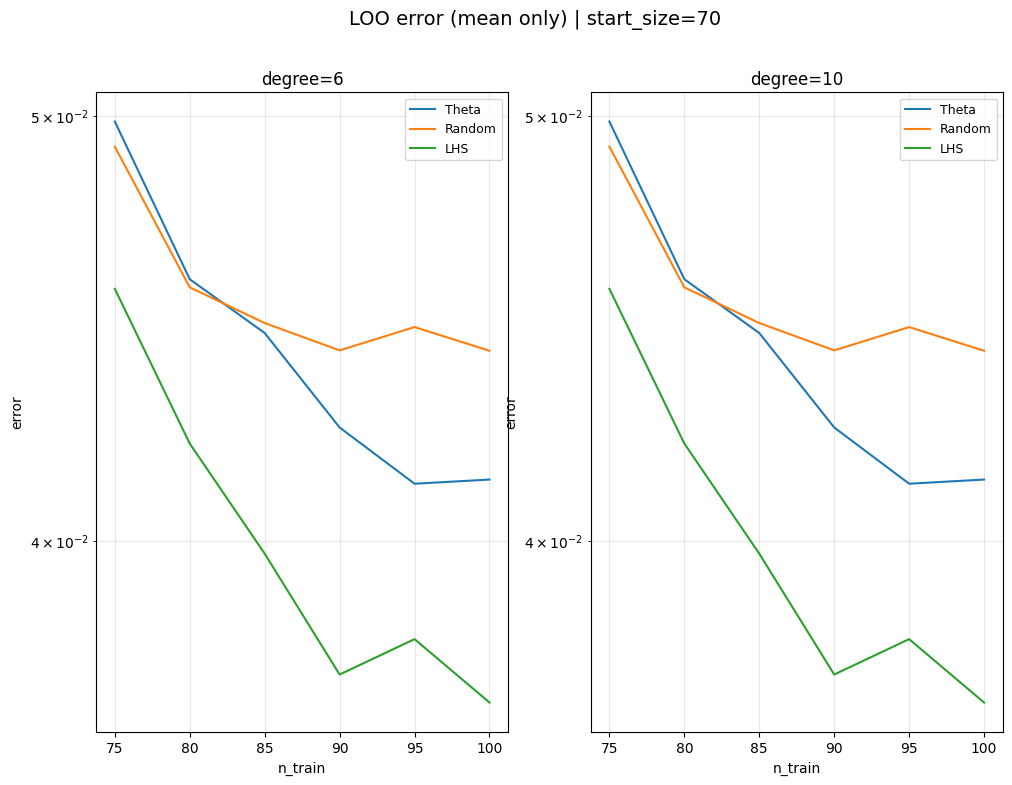

In [6]:
t_start_all = time.time()  

data_raw = pd.read_csv("Oakwood_NVM.csv", sep=";", header=0, dtype=str)  # Nacteni dat 
data = data_raw.applymap(lambda s: s.replace(",", ".") if isinstance(s, str) else s) 
data = data.apply(pd.to_numeric, errors="coerce")

names = data.columns.tolist()
arr = data.to_numpy()

X_raw = arr[:, :12].astype(float)  # Vstupy X a vystupy Y.
Y_all = arr[:, 12:].astype(float)  # X jsou vstupy a Y jsou odezvy modelu.

Y_N = Y_all[:, :113].astype(float)  # Vezmu prvnich 113 vystupu.
X = X_raw.copy()  # Resim jen sadu N vystupu.
with np.errstate(divide="ignore", invalid="ignore"):
    X[:, 0] = np.log(X[:, 0])  # Nastavim X a udelam log transform Ec

n_samples = X.shape[0]
n_inputs = X.shape[1]
n_outputs = Y_N.shape[1]

print(f"Oakwood_NVM.csv loaded: X={X.shape}, Y_N={Y_N.shape}")

dist_Ec = Normal(13, 1)  # Nastavim rozdeleni pro joint pdf.
dist_Relax = Uniform(loc=30, scale=40) 

dist_S1_Erel = Uniform(loc=2, scale=1)  # Soil1.
dist_S1_E50 = Normal(65, 5)  
dist_S1_c = Normal(30, 5)
dist_S1_theta = Normal(30, 1)
dist_S1_ko = Uniform(loc=0.6, scale=0.5)

dist_S2_Erel = Uniform(loc=2, scale=1)  # Soil2.
dist_S2_E50 = Normal(130, 10)  # Parametry druhe vrstvy zeminy
dist_S2_c = Normal(5, 1)
dist_S2_theta = Normal(42, 1)
dist_S2_ko = Uniform(loc=0.45, scale=0.2)

marginals = [
    dist_Ec,
    dist_Relax,
    dist_S1_Erel,
    dist_S1_E50,
    dist_S1_c,
    dist_S1_theta,
    dist_S1_ko,
    dist_S2_Erel,
    dist_S2_E50,
    dist_S2_c,
    dist_S2_theta,
    dist_S2_ko,
]
joint = JointIndependent(marginals=marginals)

degree_list = [6, 10]  # Nastaveni experimentu.
cr = 0.000001

start_size_list = [30, 70]
final_train_size = 100

batch_size = 5
n_test_target = 100

theta_n_pick = 113
theta_focus_k = 50

max_cond_selection = 1e3
max_cond_eval = 1e3

seed = 1

print(f"degree_list={degree_list}")
print(f"start_size_list={start_size_list}")
print(f"final_train_size={final_train_size}")
print(f"batch_size={batch_size}, cr={cr}")
print(f"n_test_target={n_test_target}")
print(f"seed={seed}")

xmin = np.nanmin(X, axis=0)  # Udelam globalni minmax pro LHS.
xmax = np.nanmax(X, axis=0)

rows = []
error_store = defaultdict(lambda: {"n_train": [], "errs": []})

for n_start in start_size_list:
    n_add_total = int(final_train_size - n_start)  # Spocitam pocet pridanych bodu.
    if n_add_total <= 0:
        raise ValueError("final_train_size must be larger than start_size.")

    add_steps = list(range(batch_size, n_add_total + 1, batch_size))  # Pripravim kroky po davkach.

    rng = np.random.RandomState(seed)  # Udelam fixni split na start, test, kandidaty.
    all_idx = np.arange(n_samples)

    start_idx = rng.choice(all_idx, size=n_start, replace=False)
    remaining = np.setdiff1d(all_idx, start_idx, assume_unique=False)
    # Kontrola jestli je dost dat - kandidatů
    if remaining.size <= n_add_total:
        raise ValueError("Not enough data left for candidates.")

    n_test = int(min(n_test_target, remaining.size - n_add_total))
    if n_test <= 0:
        raise ValueError("Not enough data left for test set.")

    test_idx = rng.choice(remaining, size=n_test, replace=False)
    cand_idx = np.setdiff1d(remaining, test_idx, assume_unique=False)

    if cand_idx.size < n_add_total:
        raise ValueError("Not enough candidates to add.")

    print("\nFixed split")
    print(f"n_start={n_start}, n_add_total={n_add_total}, n_test={n_test}")
    print(f"start_idx: n={len(start_idx)}")
    print(f"test_idx : n={len(test_idx)}")
    print(f"cand_idx : n={len(cand_idx)}")

    rand_body_idx = rng.choice(cand_idx, size=n_add_total, replace=False)  # Predpripravim random poradi.
    lhs_body_idx = pick_lhs_candidates(joint, X[cand_idx], cand_idx, n_add_total, seed, xmin, xmax)  # Predpripravim LHS poradi z realnych kandidatu.

    X_test = X[test_idx]  # Pripravim test data jednou.
    Y_test = Y_N[test_idx]

    for deg in degree_list:
        print(f"\nRUN: start_size={n_start} | seed={seed} | degree={deg}")

        theta_out_idx = (
            np.arange(n_outputs, dtype=int)
            if theta_n_pick >= n_outputs
            else np.unique(np.round(np.linspace(0, n_outputs - 1, theta_n_pick)).astype(int))
        )  # Vyberu indexy vystupu pro theta.

        theta_body_idx = pick_theta_candidates(  # Vyberu theta body po davkach.
            joint=joint,
            X_all=X,
            Y_all=Y_N,
            start_idx=start_idx,
            cand_idx=cand_idx,
            n_inputs=n_inputs,
            deg=deg,
            cr=cr,
            max_cond=max_cond_selection,
            theta_out_idx=theta_out_idx,
            theta_focus_k=theta_focus_k,
            batch_size=batch_size,
            n_total_add=n_add_total,
            seed=seed,
            X_test=X_test,
            Y_test=Y_test,
        )

        for n_added in add_steps:
            n_train = int(n_start + n_added)

            train_rand_idx = np.concatenate([start_idx, rand_body_idx[:n_added]])  # Slozim trenovaci indexy pro random.
            X_rand = X[train_rand_idx]
            Y_rand = Y_N[train_rand_idx]

            train_lhs_idx = np.concatenate([start_idx, lhs_body_idx[:n_added]])  # Slozim trenovaci indexy pro LHS.
            X_lhs = X[train_lhs_idx]
            Y_lhs = Y_N[train_lhs_idx]

            train_theta_idx = np.concatenate([start_idx, theta_body_idx[:n_added]])  # Slozim trenovaci indexy pro theta.
            X_th = X[train_theta_idx]
            Y_th = Y_N[train_theta_idx]

            pce_rand = fit_sapce_pce(joint, X_rand, Y_rand, n_inputs, deg, cr, max_cond=max_cond_eval, silent=True)  # SAPCE pro random.
            uq_rand = uqpy_val_error(pce_rand, X, Y_N).reshape(-1) # Valid. chyba na X.  
            uq_mean_rand = float(np.nanmean(uq_rand)) # Průměr chyb bez NaN.
            uq_p05_rand = safe_percentile(uq_rand, 5)   # 5% percentil chyb. 
            uq_p95_rand = safe_percentile(uq_rand, 95) # 95% percentil chyb.    
            loo_rand = try_get_loo_error(pce_rand, X_train=X_rand, Y_train=Y_rand).reshape(-1)
            loo_mean_rand = float(np.nanmean(loo_rand)) # Získej LOO
            loo_p05_rand = safe_percentile(loo_rand, 5) # 5% percentil LOO. 
            loo_p95_rand = safe_percentile(loo_rand, 95) # 95% percentil LOO. 

            pce_lhs = fit_sapce_pce(joint, X_lhs, Y_lhs, n_inputs, deg, cr, max_cond=max_cond_eval, silent=True)  # Fitnu SAPCE pro LHS.
            uq_lhs =uqpy_val_error(pce_lhs, X, Y_N).reshape(-1)
            uq_mean_lhs = float(np.nanmean(uq_lhs))
            uq_p05_lhs = safe_percentile(uq_lhs, 5)
            uq_p95_lhs = safe_percentile(uq_lhs, 95)
            loo_lhs = try_get_loo_error(pce_lhs, X_train=X_lhs, Y_train=Y_lhs).reshape(-1)
            loo_mean_lhs = float(np.nanmean(loo_lhs))
            loo_p05_lhs = safe_percentile(loo_lhs, 5)
            loo_p95_lhs = safe_percentile(loo_lhs, 95)

            pce_theta = fit_sapce_pce(joint, X_th, Y_th, n_inputs, deg, cr, max_cond=max_cond_eval, silent=True)  # Fitnu SAPCE pro theta.
            uq_theta = uqpy_val_error(pce_theta, X, Y_N).reshape(-1)
            uq_mean_theta = float(np.nanmean(uq_theta))
            uq_p05_theta = safe_percentile(uq_theta, 5)
            uq_p95_theta = safe_percentile(uq_theta, 95)
            loo_theta = try_get_loo_error(pce_theta, X_train=X_th, Y_train=Y_th).reshape(-1)
            loo_mean_theta = float(np.nanmean(loo_theta))
            loo_p05_theta = safe_percentile(loo_theta, 5)
            loo_p95_theta = safe_percentile(loo_theta, 95)

            rows.append(  # Ulozim radek vysledku.
                {
                    "start_size": int(n_start),
                    "seed": int(seed),
                    "degree": int(deg),
                    "n_added": int(n_added),
                    "uqpy_val_err_mean_theta": uq_mean_theta,
                    "uqpy_val_err_p05_theta": uq_p05_theta,
                    "uqpy_val_err_p95_theta": uq_p95_theta,
                    "uqpy_val_err_mean_random": uq_mean_rand,
                    "uqpy_val_err_p05_random": uq_p05_rand,
                    "uqpy_val_err_p95_random": uq_p95_rand,
                    "uqpy_val_err_mean_lhs": uq_mean_lhs,
                    "uqpy_val_err_p05_lhs": uq_p05_lhs,
                    "uqpy_val_err_p95_lhs": uq_p95_lhs,
                    "loo_err_mean_theta": loo_mean_theta,
                    "loo_err_p05_theta": loo_p05_theta,
                    "loo_err_p95_theta": loo_p95_theta,
                    "loo_err_mean_random": loo_mean_rand,
                    "loo_err_p05_random": loo_p05_rand,
                    "loo_err_p95_random": loo_p95_rand,
                    "loo_err_mean_lhs": loo_mean_lhs,
                    "loo_err_p05_lhs": loo_p05_lhs,
                    "loo_err_p95_lhs": loo_p95_lhs,
                }
            )

            error_store[(int(n_start), int(deg), "Theta", "UQpy validation error")]["n_train"].append(n_train)  # Ulozim i per-output chyby pro multi-line grafy.
            error_store[(int(n_start), int(deg), "Theta", "UQpy validation error")]["errs"].append(uq_theta.copy())  # Per-output grafy ukazuji rozptyl.
            error_store[(int(n_start), int(deg), "Random", "UQpy validation error")]["n_train"].append(n_train)
            error_store[(int(n_start), int(deg), "Random", "UQpy validation error")]["errs"].append(uq_rand.copy())
            error_store[(int(n_start), int(deg), "LHS", "UQpy validation error")]["n_train"].append(n_train)
            error_store[(int(n_start), int(deg), "LHS", "UQpy validation error")]["errs"].append(uq_lhs.copy())

            error_store[(int(n_start), int(deg), "Theta", "LOO error")]["n_train"].append(n_train)
            error_store[(int(n_start), int(deg), "Theta", "LOO error")]["errs"].append(loo_theta.copy())
            error_store[(int(n_start), int(deg), "Random", "LOO error")]["n_train"].append(n_train)
            error_store[(int(n_start), int(deg), "Random", "LOO error")]["errs"].append(loo_rand.copy())
            error_store[(int(n_start), int(deg), "LHS", "LOO error")]["n_train"].append(n_train)
            error_store[(int(n_start), int(deg), "LHS", "LOO error")]["errs"].append(loo_lhs.copy())

for k, pack in list(error_store.items()):  # Prevedu listy na matice (n_steps x n_outputs).
    n_train = np.asarray(pack["n_train"], int)  # Snadne vykresleni v multi-line PDF.
    errs_list = [np.asarray(e, float).reshape(1, -1) for e in pack["errs"]]
    if len(errs_list) == 0:
        error_store[k]["n_train"] = np.array([], int)
        error_store[k]["errs"] = np.zeros((0, n_outputs), float)
        continue
    E = np.vstack(errs_list)
    if E.shape[1] == 1 and n_outputs > 1:
        E = np.repeat(E, repeats=n_outputs, axis=1)
    error_store[k]["n_train"] = n_train
    error_store[k]["errs"] = E

total_time = time.time() - t_start_all
print(f"\nTotal runtime: {total_time:.2f} s")

results = pd.DataFrame(rows).sort_values(["start_size", "seed", "degree", "n_added"]).reset_index(drop=True)  # Udelam DataFrame a ulozim tabulky.

out_csv = "results_theta_random_lhs_uqpy_loo_excel.csv"  # CSV pro Excel se stredniky.
results.to_csv(out_csv, index=False, sep=";", decimal=",", encoding="utf-8-sig")  # Snadne otevreni v Excelu.
print(f"Saved: {out_csv}")

out_xlsx = "results_theta_random_lhs_uqpy_loo.xlsx"  # XLSX
results.to_excel(out_xlsx, index=False)  # Nejlepsi format pro tabulkove prohlizeni.
print(f"Saved: {out_xlsx}")

n_nan_loo = int(
    np.sum(
        ~np.isfinite(results["loo_err_mean_theta"].values)
        | ~np.isfinite(results["loo_err_mean_random"].values)
        | ~np.isfinite(results["loo_err_mean_lhs"].values)
    )
)  # Rychla kontrola NaN u LOO.
print(f"LOO NaN rows: {n_nan_loo}") 

out_pdf_mean = "comparison_theta_random_lhs.pdf"  # Vykreslim porovnani metod do PDF.
plot_pdf_summary(results, out_pdf=out_pdf_mean)  # Report pro porovnani metod.
print(f"Saved: {out_pdf_mean}")

out_pdf_multiline = "comparison_theta_random_lhs_multiline.pdf"  # Vykreslim multi-line chybovost do PDF.
plot_pdf_multiline(error_store, out_pdf=out_pdf_multiline, max_curves=None)  # Vidim chovani kazdeho vystupu.
print(f"Saved: {out_pdf_multiline}")

plot_console_means(results) 